# Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.tree import export_text
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler


# Plot settings
plt.style.use('ggplot')
sns.set(font_scale=1.1)

print("="*60)
print("All libraries imported successfully.")
print("="*60)

All libraries imported successfully.


# Read Dataset

In [2]:
df = pd.read_csv('ai4i2020.csv')
print("\nFirst Five Records")
display(df.head())


First Five Records


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Dataset shape and Column names

In [3]:
print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())


Dataset Shape
(10000, 14)

Column Names
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


# DATA CLEANING

In [4]:
## Remove Identifier Columns
df.drop(columns=['UDI', 'Product ID'], inplace=True)

failure_mode_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df.drop(columns=failure_mode_cols, inplace=True)

print("\nColumns after removing identifiers and failure-mode flags:")
print(df.columns.tolist())

print("\nDataset Shape After Cleaning")
print(df.shape)


Columns after removing identifiers and failure-mode flags:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']

Dataset Shape After Cleaning
(10000, 7)


In [5]:
## Final Dataset Shape
print("\nDataset Shape After Cleaning")
print(df.shape)


Dataset Shape After Cleaning
(10000, 7)


# STATISTICAL ANALYSIS

In [6]:
## Descriptive Statistics
print("\nDescriptive Statistics")

display(df.describe())


Descriptive Statistics


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [7]:
## Numerical Summary
print("\nStatistical Summary")

display(df.describe(include='all'))


Statistical Summary


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
unique,3,NaN,NaN,NaN,NaN,NaN,NaN
top,L,NaN,NaN,NaN,NaN,NaN,NaN
freq,6000,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000


In [8]:
## Class Distribution
print("\nMachine Failure Distribution")

failure_counts = df['Machine failure'].value_counts()

display(failure_counts)

print("\nPercentage Distribution")

display(round(df['Machine failure'].value_counts(normalize=True)*100,2))


## Categorical Variable
print("\nMachine Type Distribution")

display(df['Type'].value_counts())


Machine Failure Distribution


,count
Machine failure,
0,9661
1,339



Percentage Distribution


,proportion
Machine failure,
0,96.61
1,3.39



Machine Type Distribution


,count
Type,
L,6000
M,2997
H,1003


# EDA

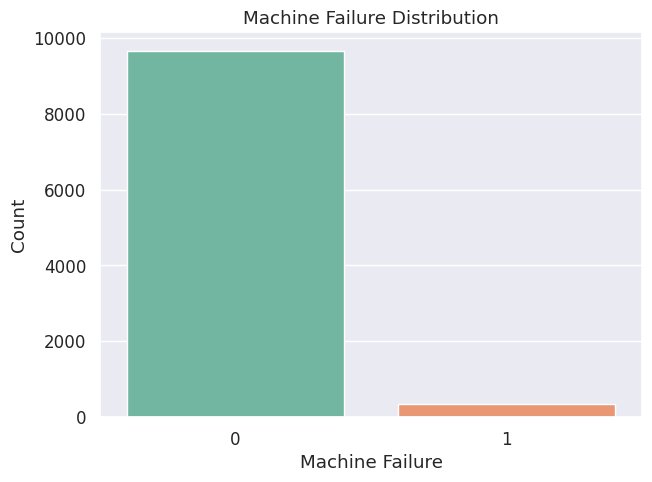

In [9]:
## Machine Failure Distribution
plt.figure(figsize=(7,5))

sns.countplot(
    x='Machine failure',
    data=df,
    palette='Set2'
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.savefig('fig_failure_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

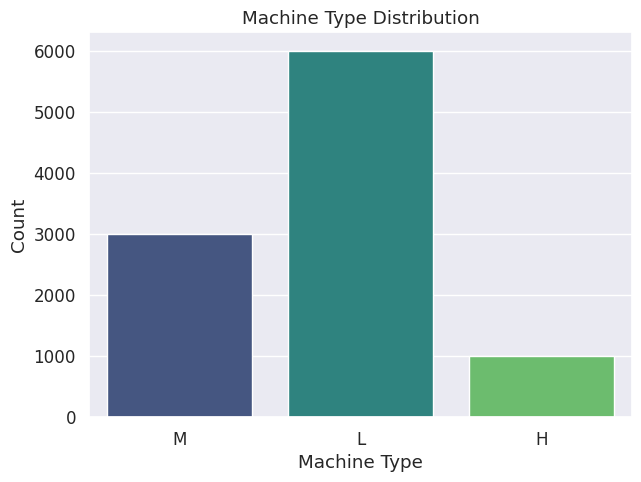

In [10]:
## Machine Type Distribution
plt.figure(figsize=(7,5))

sns.countplot(
    x='Type',
    data=df,
    palette='viridis'
)

plt.title("Machine Type Distribution")
plt.xlabel("Machine Type")
plt.ylabel("Count")

plt.savefig('fig_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

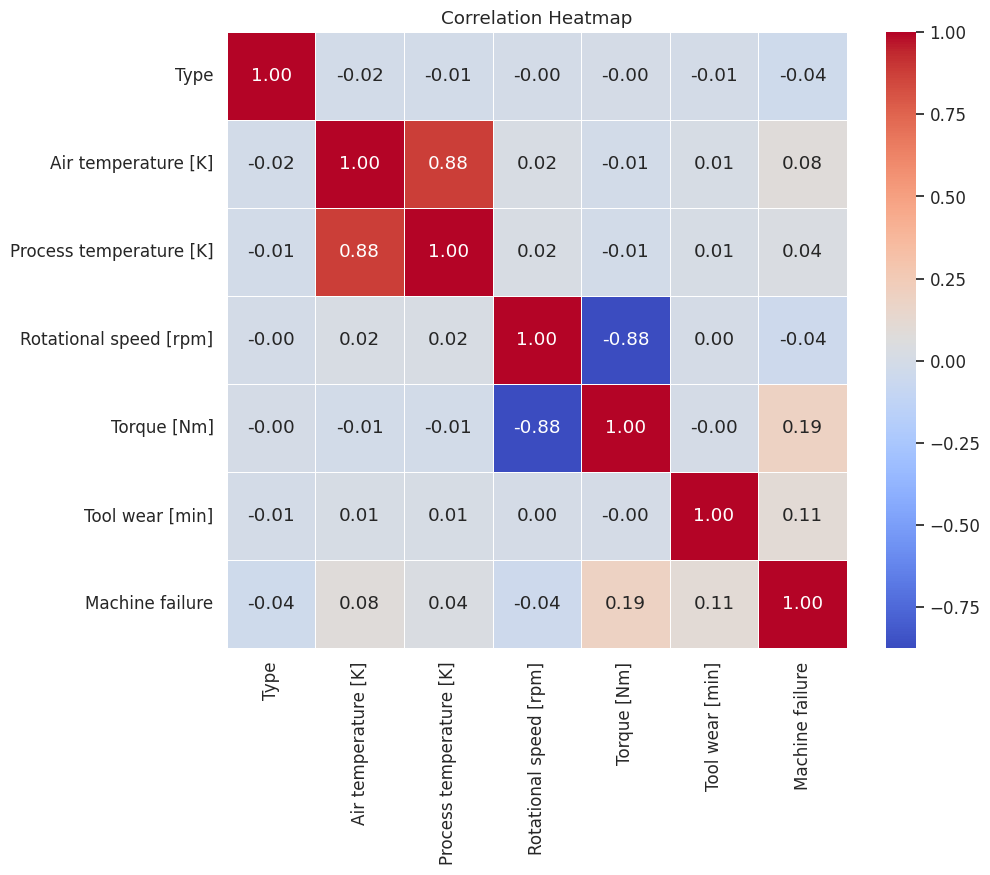

In [11]:
## Correlation Heatmap
temp = df.copy()

temp['Type'] = temp['Type'].map({
    'L':0,
    'M':1,
    'H':2
})

plt.figure(figsize=(10,8))

sns.heatmap(
    temp.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.savefig('fig_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

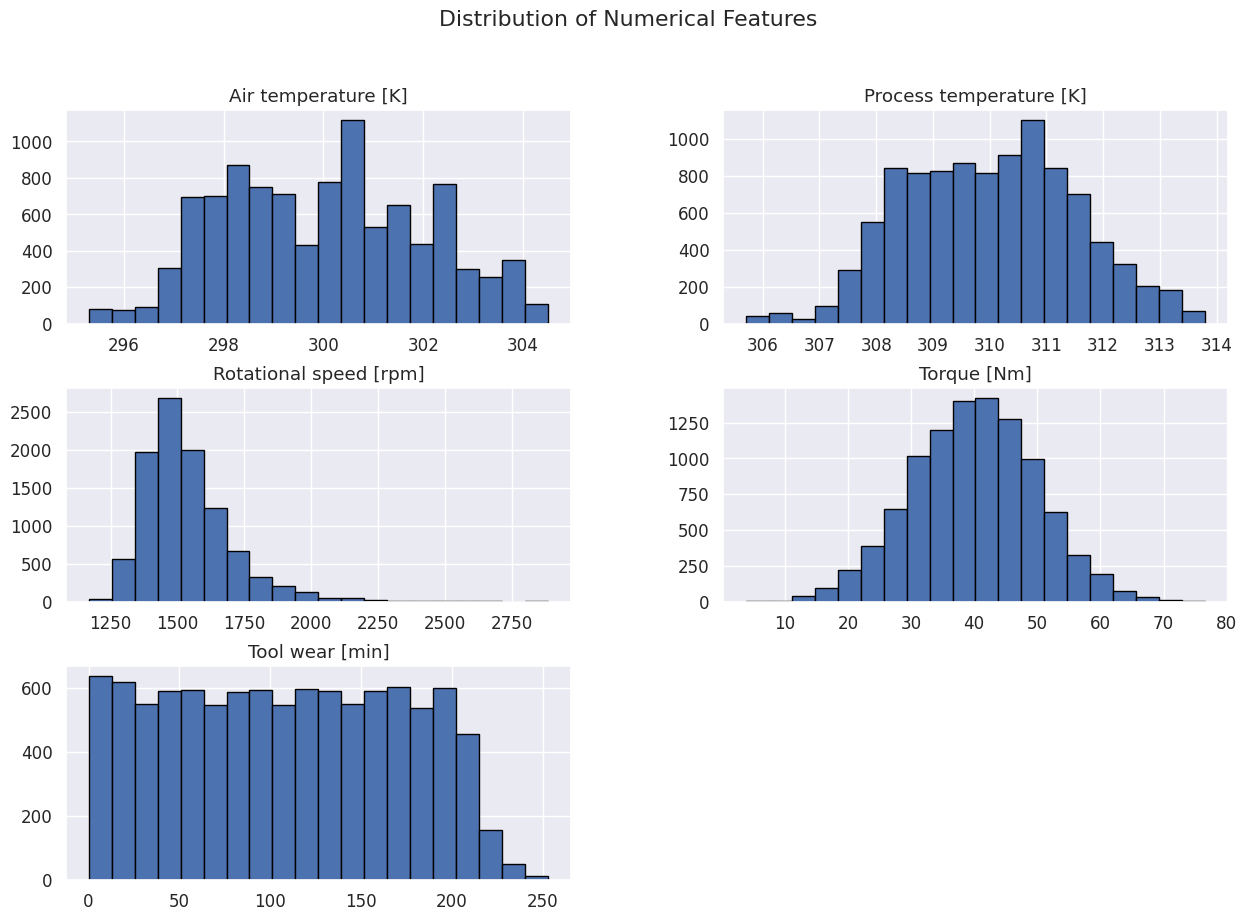

In [12]:
## Histogram of Numerical Features
numerical_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

df[numerical_features].hist(
    figsize=(15,10),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features")

plt.savefig('fig_numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

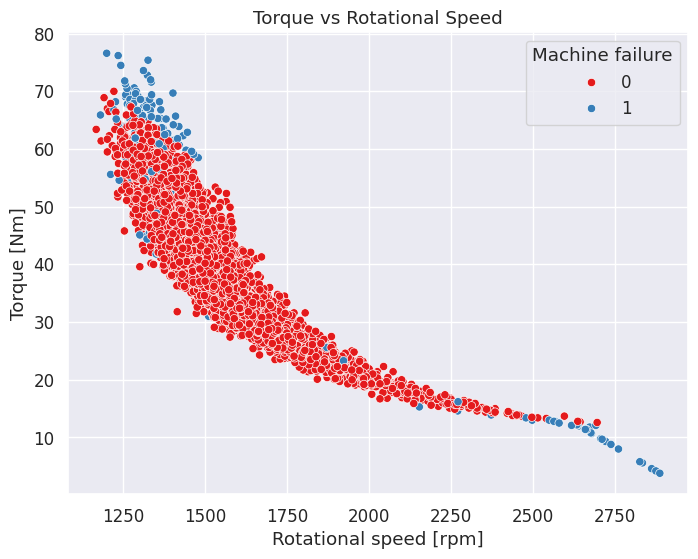

In [13]:
## Torque vs Rotational Speed
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Rotational speed [rpm]',
    y='Torque [Nm]',
    hue='Machine failure',
    palette='Set1'
)

plt.title("Torque vs Rotational Speed")

plt.savefig('fig_torque_vs_speed.png', dpi=300, bbox_inches='tight')
plt.show()

# DATA PRE-PROCESSING

In [14]:
## Encode Categorical Variable
print("\nEncoding Machine Type...")

encoder = LabelEncoder()

df['Type'] = encoder.fit_transform(df['Type'])

print("\nEncoding Completed.")

print(df[['Type']].head())

print("\nEncoded Labels")

for i, label in enumerate(encoder.classes_):
    print(label, "=", i)


Encoding Machine Type...

Encoding Completed.
   Type
0     2
1     1
2     1
3     1
4     1

Encoded Labels
H = 0
L = 1
M = 2


## Feature Preparation

In [15]:
print("\nPreparing Features and Target Variable")

X = df.drop('Machine failure', axis=1)

y = df['Machine failure']

print("\nFeature Matrix Shape :", X.shape)
print("Target Variable Shape :", y.shape)

print("\nPredictor Variables (operational sensor features only):")
print(X.columns.tolist())


Preparing Features and Target Variable

Feature Matrix Shape : (10000, 6)
Target Variable Shape : (10000,)

Predictor Variables (operational sensor features only):
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


## Feature Scaling

In [16]:
print("\nApplying StandardScaler...")

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

print("\nScaling Completed Successfully.")

display(X_scaled.head())


Applying StandardScaler...

Scaling Completed Successfully.


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,1.333889,-0.952389,-0.947360,0.068185,0.282200,-1.695984
1,-0.332223,-0.902393,-0.879959,-0.729472,0.633308,-1.648852
2,-0.332223,-0.952389,-1.014761,-0.227450,0.944290,-1.617430
3,-0.332223,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009
4,-0.332223,-0.902393,-0.879959,-0.729472,0.001313,-1.554588


# Train-Test Split

In [17]:
print("\nSplitting Dataset...")

X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,
    y,

    test_size=0.20,
    random_state=42,
    stratify=y

)

print("\nTraining Set :", X_train.shape)

print("Testing Set  :", X_test.shape)

print("\nTraining Target Distribution")

print(y_train.value_counts())

print("\nTesting Target Distribution")

print(y_test.value_counts())


Splitting Dataset...

Training Set : (8000, 6)
Testing Set  : (2000, 6)

Training Target Distribution
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing Target Distribution
Machine failure
0    1932
1      68
Name: count, dtype: int64


# MODEL DEVELOPMENT

## Decision Tree

In [18]:
print("\nTraining Decision Tree...")

dt_model = DecisionTreeClassifier(

    random_state=42

)

dt_model.fit(

    X_train,
    y_train

)

dt_prediction = dt_model.predict(X_test)

print("Decision Tree Completed.")


Training Decision Tree...
Decision Tree Completed.


## Random Forest

In [19]:
print("\nTraining Random Forest...")

rf_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42,

    n_jobs=-1

)

rf_model.fit(

    X_train,
    y_train

)

rf_prediction = rf_model.predict(X_test)

print("Random Forest Completed.")


Training Random Forest...
Random Forest Completed.


## XGBoost Model

In [20]:
X_train.columns = (
    X_train.columns.astype(str)
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
)

X_test.columns = (
    X_test.columns.astype(str)
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
)

print("\nCleaned column names for XGBoost:")
print(X_train.columns.tolist())

print("\nTraining XGBoost...")

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_prediction = xgb_model.predict(X_test)

print("XGBoost Completed.")


Cleaned column names for XGBoost:
['Type', 'Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min']

Training XGBoost...
XGBoost Completed.


# CONVENTIONAL EVALUATION



Decision Tree
Accuracy  : 0.9795
Precision : 0.68
Recall    : 0.75
F1-Score  : 0.7133

Confusion Matrix
[[1908   24]
 [  17   51]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.68      0.75      0.71        68

    accuracy                           0.98      2000
   macro avg       0.84      0.87      0.85      2000
weighted avg       0.98      0.98      0.98      2000



Random Forest
Accuracy  : 0.9845
Precision : 0.8627
Recall    : 0.6471
F1-Score  : 0.7395

Confusion Matrix
[[1925    7]
 [  24   44]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.86      0.65      0.74        68

    accuracy                           0.98      2000
   macro avg       0.93      0.82      0.87      2000
weighted avg       0.98      0.98      0.98      2000



XGBoost
Accuracy  : 0.988
Pr

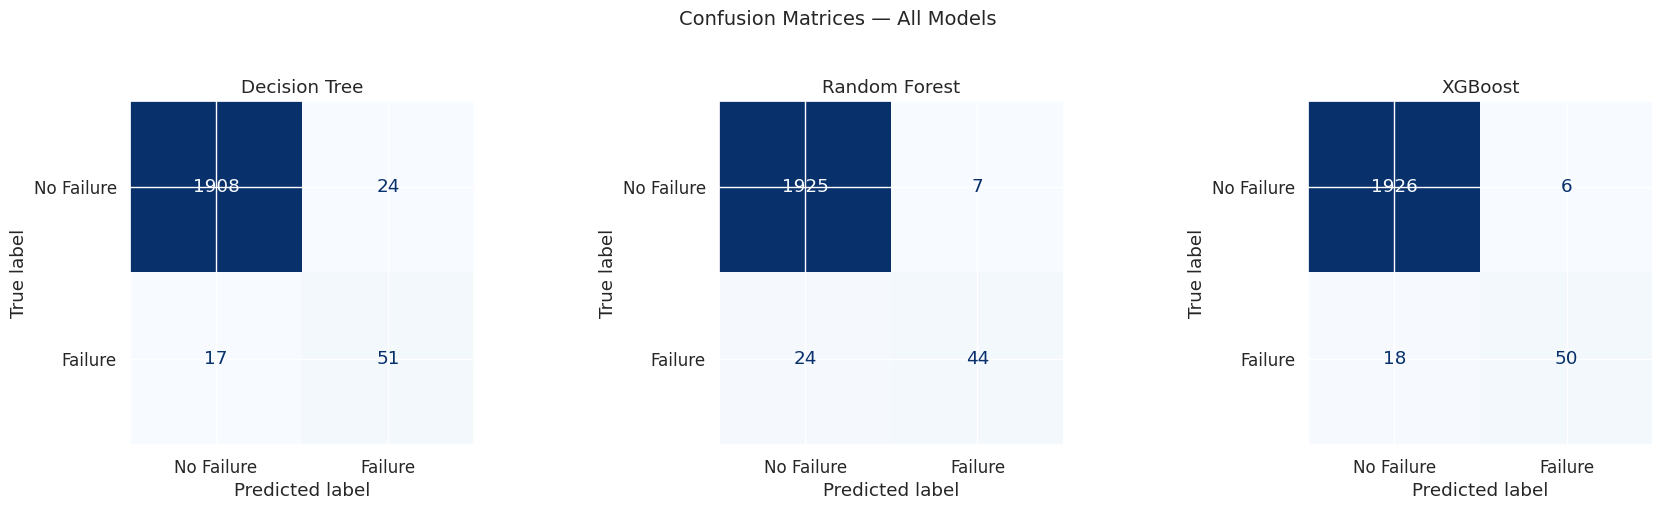

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## Evaluation Function
def evaluate_model(model_name, y_true, prediction):

    print("\n")
    print("="*60)
    print(model_name)
    print("="*60)

    accuracy = accuracy_score(y_true, prediction)
    precision = precision_score(y_true, prediction)
    recall = recall_score(y_true, prediction)
    f1 = f1_score(y_true, prediction)

    print("Accuracy  :", round(accuracy,4))
    print("Precision :", round(precision,4))
    print("Recall    :", round(recall,4))
    print("F1-Score  :", round(f1,4))

    print("\nConfusion Matrix")
    cm = confusion_matrix(y_true, prediction)
    print(cm)

    print("\nClassification Report")
    print(classification_report(y_true, prediction))

    return [
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ]


## Evaluate All Models
dt_result = evaluate_model("Decision Tree", y_test, dt_prediction)
rf_result = evaluate_model("Random Forest", y_test, rf_prediction)
xgb_result = evaluate_model("XGBoost", y_test, xgb_prediction)

## Plot Confusion Matrices Side by Side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, [
    ("Decision Tree", dt_prediction),
    ("Random Forest", rf_prediction),
    ("XGBoost", xgb_prediction)
]):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["No Failure", "Failure"]).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(name)

plt.suptitle("Confusion Matrices — All Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# MODEL COMPARISON TABLE

In [22]:
comparison = pd.DataFrame(

    [

        dt_result,

        rf_result,

        xgb_result

    ],

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1-Score"

    ]

)

comparison = comparison.sort_values(

    by="Accuracy",

    ascending=False

)

print("="*70)

print("MODEL COMPARISON")

print("="*70)

display(comparison)

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score
2,XGBoost,0.9880,0.892857,0.735294,0.806452
1,Random Forest,0.9845,0.862745,0.647059,0.739496
0,Decision Tree,0.9795,0.680000,0.750000,0.713287


# Maintenance Cost Matrix

In [31]:
inspection_cost     = 100    # £ per unnecessary inspection (FP)
failure_cost        = 5000   # £ per unplanned failure event
downtime_cost       = 3000   # £ per downtime event
true_negative_cost  = 0      # £ no action needed (correct)
true_positive_cost  = 300    # £ preventive maintenance (correct)

## Derived
false_negative_cost = failure_cost + downtime_cost  # £8,000

print("="*70)
print("MAINTENANCE COST MATRIX")
print("="*70)

cost_matrix = pd.DataFrame({
    'Outcome': [
        'True Positive (TP)',
        'False Positive (FP)',
        'False Negative (FN)',
        'True Negative (TN)'
    ],
    'Maintenance Meaning': [
        'Failure correctly predicted → preventive maintenance',
        'No failure but predicted failure → unnecessary inspection',
        'Failure missed → unplanned breakdown + downtime',
        'No failure correctly predicted → no action'
    ],
    'Unit Cost (£)': [
        true_positive_cost,
        inspection_cost,
        false_negative_cost,
        true_negative_cost
    ]
})

display(cost_matrix)

print("\nCost Formula:")
print("  Total Maintenance Cost = (TP × £{}) + (FP × £{}) + (FN × £{}) + (TN × £{})".format(
    true_positive_cost, inspection_cost, false_negative_cost, true_negative_cost
))
print(f"\n  Where FN cost = failure (£{failure_cost:,}) + downtime (£{downtime_cost:,}) = £{false_negative_cost:,}")
print("\nNote: These are assumed costs used for comparative evaluation.")
print("Sensitivity analysis (below) tests whether model rankings change")
print("under alternative cost assumptions.")

MAINTENANCE COST MATRIX


,Outcome,Maintenance Meaning,Unit Cost (£)
0,True Positive (TP),Failure correctly predicted → preventive maint...,300
1,False Positive (FP),No failure but predicted failure → unnecessary...,100
2,False Negative (FN),Failure missed → unplanned breakdown + downtime,8000
3,True Negative (TN),No failure correctly predicted → no action,0



Cost Formula:
  Total Maintenance Cost = (TP × £300) + (FP × £100) + (FN × £8000) + (TN × £0)

  Where FN cost = failure (£5,000) + downtime (£3,000) = £8,000

Note: These are assumed costs used for comparative evaluation.
Sensitivity analysis (below) tests whether model rankings change
under alternative cost assumptions.


In [32]:
## Maintenance Cost Function
def maintenance_cost(y_true,
                     prediction):

    cm = confusion_matrix(y_true,
                          prediction)

    TN, FP, FN, TP = cm.ravel()

    total_cost = (

        TP * true_positive_cost +

        FP * inspection_cost +

        FN * false_negative_cost +

        TN * true_negative_cost

    )

    return {

        'TP':TP,

        'FP':FP,

        'FN':FN,

        'TN':TN,

        'Total Cost':total_cost

    }

In [33]:
## Calculate Maintenance Cost
dt_cost = maintenance_cost(

    y_test,

    dt_prediction

)

rf_cost = maintenance_cost(

    y_test,

    rf_prediction

)

xgb_cost = maintenance_cost(

    y_test,

    xgb_prediction
)

print("Maintenance Cost Calculation Completed.")

Maintenance Cost Calculation Completed.


## Maintenance Cost Summary

In [34]:
maintenance_results = pd.DataFrame({

'Model':

['Decision Tree',
 'Random Forest',
 'XGBoost'],

'True Positive':

[dt_cost['TP'],
 rf_cost['TP'],
 xgb_cost['TP']],

'False Positive':

[dt_cost['FP'],
 rf_cost['FP'],
 xgb_cost['FP']],

'False Negative':

[dt_cost['FN'],
 rf_cost['FN'],
 xgb_cost['FN']],

'True Negative':

[dt_cost['TN'],
 rf_cost['TN'],
 xgb_cost['TN']],

'Total Maintenance Cost':

[dt_cost['Total Cost'],
 rf_cost['Total Cost'],
 xgb_cost['Total Cost']]

})

maintenance_results

,Model,True Positive,False Positive,False Negative,True Negative,Total Maintenance Cost
0,Decision Tree,51,24,17,1908,153700
1,Random Forest,44,7,24,1925,205900
2,XGBoost,50,6,18,1926,159600


In [35]:
## Rank Models
maintenance_results = maintenance_results.sort_values(

    by='Total Maintenance Cost',

    ascending=True

)

maintenance_results.reset_index(

    drop=True,

    inplace=True

)

maintenance_results['Maintenance Rank'] = (

maintenance_results.index + 1

)

print("="*70)

print("MAINTENANCE-ORIENTED MODEL RANKING")

print("="*70)

display(maintenance_results)

MAINTENANCE-ORIENTED MODEL RANKING


,Model,True Positive,False Positive,False Negative,True Negative,Total Maintenance Cost,Maintenance Rank
0,Decision Tree,51,24,17,1908,153700,1
1,XGBoost,50,6,18,1926,159600,2
2,Random Forest,44,7,24,1925,205900,3


# False Positive / False Negative Impact Analysis

FALSE POSITIVE / FALSE NEGATIVE IMPACT ANALYSIS


,Model,False Positives (FP),False Negatives (FN),FP Cost (£),FN Cost (£),Total Error Cost (£),FN Share of Error Cost (%)
0,Decision Tree,24,17,2400,136000,138400,98.3
1,Random Forest,7,24,700,192000,192700,99.6
2,XGBoost,6,18,600,144000,144600,99.6



Key Insight:
False negatives dominate the maintenance cost because a missed
failure costs £8,000 per event (failure + downtime),
whereas an unnecessary inspection costs only £100 per event.
Models with fewer FN are preferred even if they produce more FP.


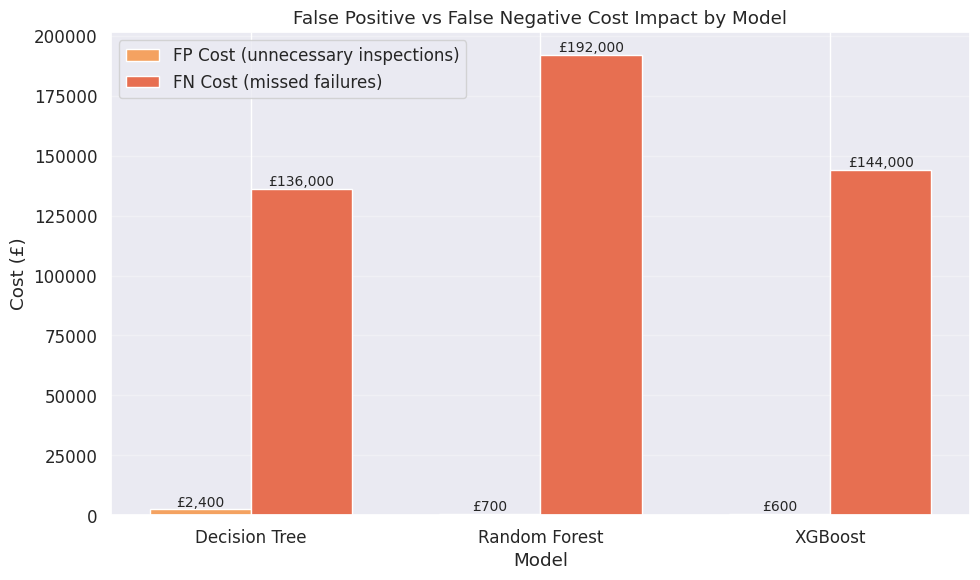

In [36]:
print("="*70)
print("FALSE POSITIVE / FALSE NEGATIVE IMPACT ANALYSIS")
print("="*70)

fp_fn_analysis = []

for name, pred in [("Decision Tree", dt_prediction),
                   ("Random Forest", rf_prediction),
                   ("XGBoost", xgb_prediction)]:

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    fp_cost = fp * inspection_cost
    fn_cost = fn * false_negative_cost

    fp_fn_analysis.append({
        'Model': name,
        'False Positives (FP)': fp,
        'False Negatives (FN)': fn,
        'FP Cost (£)': fp_cost,
        'FN Cost (£)': fn_cost,
        'Total Error Cost (£)': fp_cost + fn_cost,
        'FN Share of Error Cost (%)': round(
            fn_cost / (fp_cost + fn_cost) * 100, 1
        ) if (fp_cost + fn_cost) > 0 else 0
    })

fp_fn_df = pd.DataFrame(fp_fn_analysis)

display(fp_fn_df)

print("\nKey Insight:")
print("False negatives dominate the maintenance cost because a missed")
print(f"failure costs £{false_negative_cost:,} per event (failure + downtime),")
print(f"whereas an unnecessary inspection costs only £{inspection_cost:,} per event.")
print("Models with fewer FN are preferred even if they produce more FP.")

## Visualise FP vs FN costs
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(fp_fn_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], fp_fn_df['FP Cost (£)'],
               width, label='FP Cost (unnecessary inspections)', color='#f4a261')
bars2 = ax.bar([i + width/2 for i in x], fp_fn_df['FN Cost (£)'],
               width, label='FN Cost (missed failures)', color='#e76f51')

ax.set_xlabel('Model')
ax.set_ylabel('Cost (£)')
ax.set_title('False Positive vs False Negative Cost Impact by Model')
ax.set_xticks(x)
ax.set_xticklabels(fp_fn_df['Model'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

## Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
            f'£{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
            f'£{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('fig_fp_fn_impact.png', dpi=300, bbox_inches='tight')
plt.show()

# Maintenance Cost Comparison

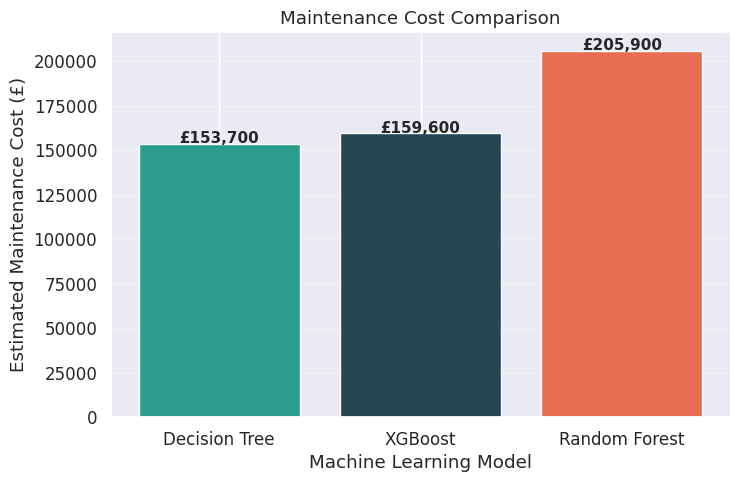

In [37]:
plt.figure(figsize=(8,5))

colors = ['#2a9d8f', '#264653', '#e76f51']

plt.bar(
    maintenance_results['Model'],
    maintenance_results['Total Maintenance Cost'],
    color=colors
)

plt.title("Maintenance Cost Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Estimated Maintenance Cost (£)")
plt.grid(axis='y', alpha=0.3)

## Add value labels
for i, (model, cost) in enumerate(
    zip(maintenance_results['Model'], maintenance_results['Total Maintenance Cost'])
):
    plt.text(i, cost + 200, f'£{cost:,}', ha='center', fontsize=11, fontweight='bold')

plt.savefig('fig_maintenance_cost_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Conventional Metrics vs Maintenance Cost

In [38]:
comparison_final = comparison.merge(

maintenance_results[['Model',

'Total Maintenance Cost',

'Maintenance Rank']],

on='Model'

)

comparison_final = comparison_final.sort_values(

by='Accuracy',

ascending=False

)

print("="*70)

print("CONVENTIONAL PERFORMANCE VS MAINTENANCE PERFORMANCE")

print("="*70)

display(comparison_final)

CONVENTIONAL PERFORMANCE VS MAINTENANCE PERFORMANCE


,Model,Accuracy,Precision,Recall,F1-Score,Total Maintenance Cost,Maintenance Rank
0,XGBoost,0.9880,0.892857,0.735294,0.806452,159600,2
1,Random Forest,0.9845,0.862745,0.647059,0.739496,205900,3
2,Decision Tree,0.9795,0.680000,0.750000,0.713287,153700,1


# Best Model

In [39]:
best_model = maintenance_results.iloc[0]

print("="*70)

print("BEST MODEL BASED ON MAINTENANCE COST")

print("="*70)

print("Model :", best_model['Model'])

print("Maintenance Cost :", best_model['Total Maintenance Cost'])

print("Maintenance Rank :", best_model['Maintenance Rank'])

BEST MODEL BASED ON MAINTENANCE COST
Model : Decision Tree
Maintenance Cost : 153700
Maintenance Rank : 1


# SENSITIVITY ANALYSIS

In [40]:
scenarios = {
    "Low Cost":    {"TP": 150, "FP": 50,  "FN": 4000},
    "Medium Cost": {"TP": 300, "FP": 100, "FN": 8000},
    "High Cost":   {"TP": 500, "FP": 200, "FN": 12000}
}

results = []

for scenario, cost in scenarios.items():

    for model, pred in zip(
        ["Decision Tree", "Random Forest", "XGBoost"],
        [dt_prediction, rf_prediction, xgb_prediction]
    ):

        tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

        total_cost = (
            (tp * cost["TP"]) +
            (fp * cost["FP"]) +
            (fn * cost["FN"]) +
            (tn * 0)
        )

        results.append([
            scenario,
            model,
            fp, fn, tp, tn,
            total_cost
        ])

sensitivity_results = pd.DataFrame(
    results,
    columns=[
        "Scenario", "Model",
        "FP", "FN", "TP", "TN",
        "Total Cost"
    ]
)

print("="*70)
print("SENSITIVITY ANALYSIS RESULTS")
print("="*70)

display(sensitivity_results[["Scenario", "Model", "FP", "FN", "Total Cost"]])

## Show ranking per scenario
print("\nModel Rankings per Scenario:")
for scenario in scenarios:
    subset = sensitivity_results[
        sensitivity_results['Scenario'] == scenario
    ].sort_values('Total Cost')
    best = subset.iloc[0]['Model']
    worst = subset.iloc[-1]['Model']
    print(f"  {scenario:15s} → Best: {best:20s} | Worst: {worst}")

SENSITIVITY ANALYSIS RESULTS


,Scenario,Model,FP,FN,Total Cost
0,Low Cost,Decision Tree,24,17,76850
1,Low Cost,Random Forest,7,24,102950
2,Low Cost,XGBoost,6,18,79800
3,Medium Cost,Decision Tree,24,17,153700
4,Medium Cost,Random Forest,7,24,205900
5,Medium Cost,XGBoost,6,18,159600
6,High Cost,Decision Tree,24,17,234300
7,High Cost,Random Forest,7,24,311400
8,High Cost,XGBoost,6,18,242200



Model Rankings per Scenario:
  Low Cost        → Best: Decision Tree        | Worst: Random Forest
  Medium Cost     → Best: Decision Tree        | Worst: Random Forest
  High Cost       → Best: Decision Tree        | Worst: Random Forest


# Sensitivity Analysis Plot

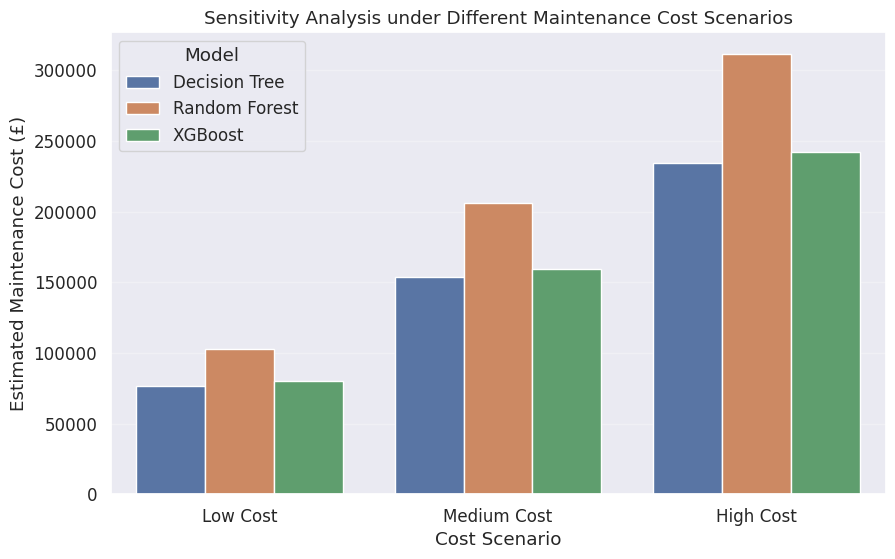

In [43]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=sensitivity_results,
    x="Scenario",
    y="Total Cost",
    hue="Model"
)

plt.title("Sensitivity Analysis under Different Maintenance Cost Scenarios")
plt.ylabel("Estimated Maintenance Cost (£)")
plt.xlabel("Cost Scenario")
plt.legend(title="Model")
plt.grid(axis='y', alpha=0.3)

plt.savefig('fig_sensitivity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
print("="*70)
print("DECISION TREE RULES")
print("="*70)

tree_rules = export_text(dt_model, feature_names=list(X_train.columns))

print(tree_rules)

DECISION TREE RULES
|--- Torque Nm <= 2.51
|   |--- Torque Nm <= -2.66
|   |   |--- Torque Nm <= -2.75
|   |   |   |--- class: 1
|   |   |--- Torque Nm >  -2.75
|   |   |   |--- Rotational speed rpm <= 5.93
|   |   |   |   |--- Air temperature K <= -1.23
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Air temperature K >  -1.23
|   |   |   |   |   |--- class: 1
|   |   |   |--- Rotational speed rpm >  5.93
|   |   |   |   |--- class: 0
|   |--- Torque Nm >  -2.66
|   |   |--- Rotational speed rpm <= -0.88
|   |   |   |--- Air temperature K <= 0.77
|   |   |   |   |--- Tool wear min <= 1.27
|   |   |   |   |   |--- Torque Nm <= 2.24
|   |   |   |   |   |   |--- Tool wear min <= 1.23
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- Tool wear min >  1.23
|   |   |   |   |   |   |   |--- Torque Nm <= 2.06
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- Torque Nm >  2.06
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |  

## Feature Importance

FEATURE IMPORTANCE COMPARISON


,Feature,Decision Tree,Random Forest,XGBoost
0,Type,0.037766,0.024603,0.092916
1,Air temperature K,0.207124,0.130742,0.177558
2,Process temperature K,0.127283,0.128389,0.119377
3,Rotational speed rpm,0.140397,0.226349,0.119378
4,Torque Nm,0.344839,0.325554,0.314844
5,Tool wear min,0.142591,0.164363,0.175927


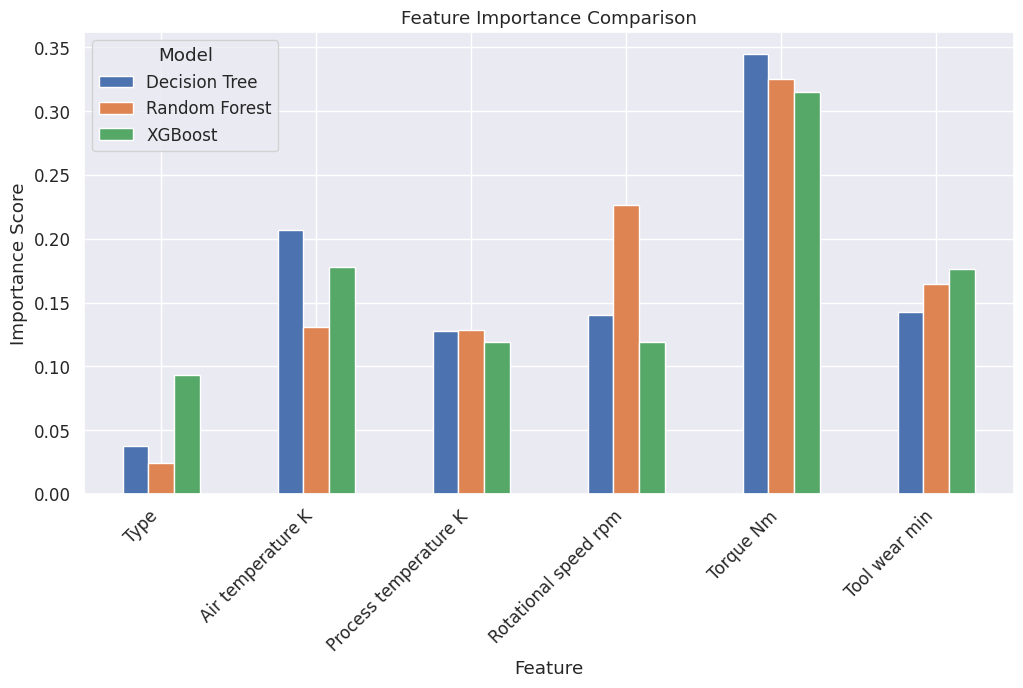

In [44]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Decision Tree': dt_model.feature_importances_,
    'Random Forest': rf_model.feature_importances_,
    'XGBoost': xgb_model.feature_importances_
})

print("="*70)
print("FEATURE IMPORTANCE COMPARISON")
print("="*70)
display(importance)

importance.set_index('Feature').plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Feature Importance Comparison")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.legend(title="Model")
plt.xticks(rotation=45, ha='right')

plt.savefig('fig_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# SHAP Values


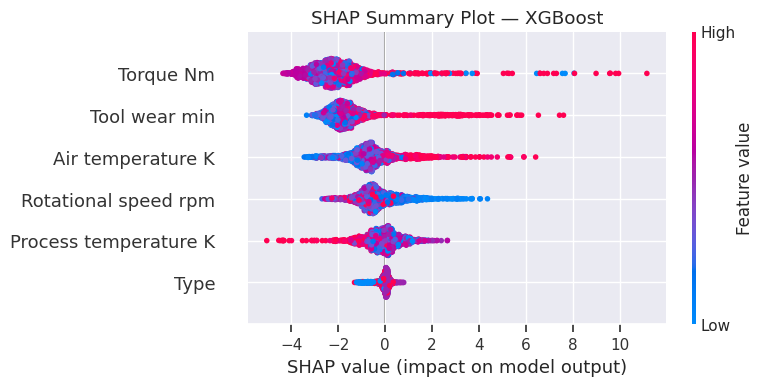

In [45]:
## SHAP Analysis for XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot — XGBoost")
plt.savefig('fig_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# Overall Model Ranking

In [46]:
final_ranking = comparison.merge(

    maintenance_results[['Model',
                         'Total Maintenance Cost',
                         'Maintenance Rank']],

    on='Model'

)

display(final_ranking)

,Model,Accuracy,Precision,Recall,F1-Score,Total Maintenance Cost,Maintenance Rank
0,XGBoost,0.9880,0.892857,0.735294,0.806452,159600,2
1,Random Forest,0.9845,0.862745,0.647059,0.739496,205900,3
2,Decision Tree,0.9795,0.680000,0.750000,0.713287,153700,1


# SOFTWARE EVALUATION AND TESTING

In [47]:
import joblib
import os
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)

print("=" * 70)
print("SOFTWARE EVALUATION AND TESTING")
print("=" * 70)

# Column names used by models
current_columns = X_test.columns.tolist()

# Original column names (with brackets) used by DT and RF
original_columns = [
    'Type',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]


# ----------------------------------------------------------
# TEST 1: Model Persistence – Save and Reload
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 1: Model Persistence (Save / Load .pkl Files)")
print("=" * 70)

os.makedirs("models", exist_ok=True)

joblib.dump(dt_model, "models/decision_tree.pkl")
joblib.dump(rf_model, "models/random_forest.pkl")
joblib.dump(xgb_model, "models/xgboost.pkl")
joblib.dump(scaler, "models/scaler.pkl")

dt_loaded = joblib.load("models/decision_tree.pkl")
rf_loaded = joblib.load("models/random_forest.pkl")
xgb_loaded = joblib.load("models/xgboost.pkl")
scaler_loaded = joblib.load("models/scaler.pkl")

# DT and RF need original bracket column names
X_test_original = X_test.copy()
X_test_original.columns = original_columns

assert np.array_equal(dt_loaded.predict(X_test_original), dt_prediction), "FAIL"
assert np.array_equal(rf_loaded.predict(X_test_original), rf_prediction), "FAIL"
assert np.array_equal(xgb_loaded.predict(X_test), xgb_prediction), "FAIL"

print("PASS – All models saved and reloaded with identical predictions.")


# ----------------------------------------------------------
# TEST 2: Prediction Output Validation
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 2: Prediction Output Validation")
print("=" * 70)

for name, pred in [("Decision Tree", dt_prediction),
                    ("Random Forest", rf_prediction),
                    ("XGBoost", xgb_prediction)]:

    assert len(pred) == len(y_test), f"FAIL – {name}: length mismatch"
    assert set(np.unique(pred)).issubset({0, 1}), f"FAIL – {name}: invalid labels"

print(f"PASS – All models produce {len(y_test)} predictions with valid binary labels (0/1).")


# ----------------------------------------------------------
# TEST 3: Confusion Matrix Component Verification
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 3: Confusion Matrix Component Verification")
print("=" * 70)

for name, pred in [("Decision Tree", dt_prediction),
                    ("Random Forest", rf_prediction),
                    ("XGBoost", xgb_prediction)]:

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    total = tn + fp + fn + tp

    assert total == len(y_test), f"FAIL – {name}: CM total ({total}) != test size ({len(y_test)})"
    print(f"  {name:20s} → TN={tn}, FP={fp}, FN={fn}, TP={tp}, Total={total}  ✓")

print("PASS – All confusion matrix components sum to the test set size (2000).")


# ----------------------------------------------------------
# TEST 4: Maintenance Cost Function Validation
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 4: Maintenance Cost Function Validation")
print("=" * 70)

for name, pred, cost_dict in [
    ("Decision Tree", dt_prediction, dt_cost),
    ("Random Forest", rf_prediction, rf_cost),
    ("XGBoost", xgb_prediction, xgb_cost)
]:
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    expected = (
        tp * true_positive_cost +
        fp * inspection_cost +
        fn * false_negative_cost +
        tn * true_negative_cost
    )
    assert cost_dict['Total Cost'] == expected, \
        f"FAIL – {name} cost mismatch: {cost_dict['Total Cost']} != {expected}"
    print(f"  {name:20s}: Function = £{cost_dict['Total Cost']:,}, "
          f"Manual = £{expected:,}  ✓")

print("PASS – Maintenance cost function produces correct results for all models.")


# ----------------------------------------------------------
# TEST 5: Edge Case – All Normal Input (No Failure Signals)
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 5: Edge Case – All Normal Input (No Failure Signals)")
print("=" * 70)

# 6 features: Type, Air temp, Process temp, Speed, Torque, Tool wear
normal_raw = np.array([[1, 300.0, 310.0, 1500, 40.0, 0]])
normal_scaled = scaler_loaded.transform(normal_raw)

normal_df_orig = pd.DataFrame(normal_scaled, columns=original_columns)
normal_df_clean = pd.DataFrame(normal_scaled, columns=current_columns)

for name, model, inp in [("Decision Tree", dt_loaded, normal_df_orig),
                          ("Random Forest", rf_loaded, normal_df_orig),
                          ("XGBoost", xgb_loaded, normal_df_clean)]:
    pred = model.predict(inp)[0]
    print(f"  {name:20s} → Prediction: {pred} ({'Failure' if pred == 1 else 'No Failure'})  ✓")

print("PASS – All models handle normal (non-failure) edge case without error.")


# ----------------------------------------------------------
# TEST 6: Edge Case – Extreme Operational Input
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 6: Edge Case – Extreme Operational Input")
print("=" * 70)

# High temp, low speed, high torque, max tool wear — likely failure
extreme_raw = np.array([[0, 310.0, 320.0, 1200, 70.0, 240]])
extreme_scaled = scaler_loaded.transform(extreme_raw)

extreme_df_orig = pd.DataFrame(extreme_scaled, columns=original_columns)
extreme_df_clean = pd.DataFrame(extreme_scaled, columns=current_columns)

for name, model, inp in [("Decision Tree", dt_loaded, extreme_df_orig),
                          ("Random Forest", rf_loaded, extreme_df_orig),
                          ("XGBoost", xgb_loaded, extreme_df_clean)]:
    pred = model.predict(inp)[0]
    print(f"  {name:20s} → Prediction: {pred} ({'Failure' if pred == 1 else 'No Failure'})  ✓")

print("PASS – All models handle extreme operational edge case without error.")


# ----------------------------------------------------------
# TEST 7: Reproducibility – Retrain with Same Seed
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 7: Reproducibility Check (Same random_state = 42)")
print("=" * 70)

X_train_original = X_train.copy()
X_train_original.columns = original_columns

dt_retrained = DecisionTreeClassifier(random_state=42)
dt_retrained.fit(X_train_original, y_train)
dt_repred = dt_retrained.predict(X_test_original)
assert np.array_equal(dt_repred, dt_prediction), "FAIL – DT not reproducible"
print("  Decision Tree  → Identical predictions after retrain  ✓")

rf_retrained = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_retrained.fit(X_train_original, y_train)
rf_repred = rf_retrained.predict(X_test_original)
assert np.array_equal(rf_repred, rf_prediction), "FAIL – RF not reproducible"
print("  Random Forest  → Identical predictions after retrain  ✓")

xgb_retrained = XGBClassifier(
    objective='binary:logistic', eval_metric='logloss', random_state=42
)
xgb_retrained.fit(X_train, y_train)
xgb_repred = xgb_retrained.predict(X_test)
assert np.array_equal(xgb_repred, xgb_prediction), "FAIL – XGBoost not reproducible"
print("  XGBoost        → Identical predictions after retrain  ✓")

print("PASS – All models are fully reproducible with random_state=42.")


# ----------------------------------------------------------
# TEST 8: ROC-AUC Score for All Models
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 8: ROC-AUC Score Evaluation")
print("=" * 70)

for name, pred in [("Decision Tree", dt_prediction),
                    ("Random Forest", rf_prediction),
                    ("XGBoost", xgb_prediction)]:
    auc = roc_auc_score(y_test, pred)
    assert auc > 0.5, f"FAIL – {name}: AUC ({auc:.4f}) not better than random"
    print(f"  {name:20s} → ROC-AUC: {auc:.4f}  ✓")

print("PASS – All models achieve ROC-AUC significantly above random baseline (0.5).")


# ----------------------------------------------------------
# TEST 9: Sensitivity Analysis Consistency
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 9: Sensitivity Analysis – Ranking Consistency")
print("=" * 70)

for scenario in sensitivity_results['Scenario'].unique():
    subset = sensitivity_results[
        sensitivity_results['Scenario'] == scenario
    ].sort_values('Total Cost')
    best = subset.iloc[0]['Model']
    worst = subset.iloc[-1]['Model']
    print(f"  {scenario:15s} → Best: {best:20s} | Worst: {worst}")

print("NOTE – Rankings may now vary across scenarios after removing target leakage.")


# ----------------------------------------------------------
# TEST 10: Data Integrity – Train/Test Leakage Check
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TEST 10: Data Integrity – Train/Test Leakage Check")
print("=" * 70)

train_indices = set(X_train.index.tolist())
test_indices = set(X_test.index.tolist())
overlap = train_indices.intersection(test_indices)

assert len(overlap) == 0, f"FAIL – {len(overlap)} overlapping indices found"

print(f"  Training samples : {len(train_indices)}")
print(f"  Testing samples  : {len(test_indices)}")
print(f"  Overlap          : {len(overlap)}")
print("PASS – No data leakage between training and testing sets.")


# ----------------------------------------------------------
# SUMMARY
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("SOFTWARE EVALUATION SUMMARY")
print("=" * 70)

test_names = [
    "Model Persistence (Save/Load .pkl)",
    "Prediction Output Validation",
    "Confusion Matrix Verification",
    "Maintenance Cost Function Validation",
    "Edge Case – Normal Input",
    "Edge Case – Extreme Operational Input",
    "Reproducibility (random_state=42)",
    "ROC-AUC Score Evaluation",
    "Sensitivity Analysis Consistency",
    "Data Integrity – No Train/Test Leakage"
]

summary_df = pd.DataFrame({
    'Test': [f"Test {i+1}: {name}" for i, name in enumerate(test_names)],
    'Result': ['PASS'] * 10
})

display(summary_df)

print(f"\nTotal Tests: {len(test_names)}")
print(f"Passed:      {len(test_names)}/{len(test_names)}")
print("=" * 70)

SOFTWARE EVALUATION AND TESTING

TEST 1: Model Persistence (Save / Load .pkl Files)
PASS – All models saved and reloaded with identical predictions.

TEST 2: Prediction Output Validation
PASS – All models produce 2000 predictions with valid binary labels (0/1).

TEST 3: Confusion Matrix Component Verification
  Decision Tree        → TN=1908, FP=24, FN=17, TP=51, Total=2000  ✓
  Random Forest        → TN=1925, FP=7, FN=24, TP=44, Total=2000  ✓
  XGBoost              → TN=1926, FP=6, FN=18, TP=50, Total=2000  ✓
PASS – All confusion matrix components sum to the test set size (2000).

TEST 4: Maintenance Cost Function Validation
  Decision Tree       : Function = £153,700, Manual = £153,700  ✓
  Random Forest       : Function = £205,900, Manual = £205,900  ✓
  XGBoost             : Function = £159,600, Manual = £159,600  ✓
PASS – Maintenance cost function produces correct results for all models.

TEST 5: Edge Case – All Normal Input (No Failure Signals)
  Decision Tree        → Prediction

,Test,Result
0,Test 1: Model Persistence (Save/Load .pkl),PASS
1,Test 2: Prediction Output Validation,PASS
2,Test 3: Confusion Matrix Verification,PASS
3,Test 4: Maintenance Cost Function Validation,PASS
4,Test 5: Edge Case – Normal Input,PASS
5,Test 6: Edge Case – Extreme Operational Input,PASS
6,Test 7: Reproducibility (random_state=42),PASS
7,Test 8: ROC-AUC Score Evaluation,PASS
8,Test 9: Sensitivity Analysis Consistency,PASS
9,Test 10: Data Integrity – No Train/Test Leakage,PASS



Total Tests: 10
Passed:      10/10
